In [22]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [23]:
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)
num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)

In [24]:
def scale(image, label):
  image = tf.cast(image, tf.float32)
  image /= 255.0

  return image, label

scaled_train_and_validation_data = mnist_train.map(scale)

In [25]:
BUFFER_SIZE = 1000
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)


In [26]:
BATCH_SIZE = 100

train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)

test_data = validation_data.batch(num_test_samples)

validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)

(6000, 28, 28, 1) (6000,)


In [8]:
input_size = 784
output_size =10

hidden_layer_size = 50

model = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28,28,1)),
  tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
  tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
  tf.keras.layers.Dense(output_size, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [41]:
NUM_EPOCHS = 40

early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

model.fit(
    train_data,
    epochs=NUM_EPOCHS,
    callbacks=[early_stopping],
    validation_data=(validation_inputs, validation_targets),
    verbose=1
)

Epoch 1/40
540/540 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9951 - loss: 0.0147 - val_accuracy: 0.9745 - val_loss: 0.1086
Epoch 2/40
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9970 - loss: 0.0104 - val_accuracy: 0.9713 - val_loss: 0.1176
Epoch 3/40
540/540 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9962 - loss: 0.0122 - val_accuracy: 0.9717 - val_loss: 0.1149


In [34]:
scaled_test_data = mnist_test.map(scale)
test_data = scaled_test_data.batch(BATCH_SIZE)

test_loss, test_accuracy = model.evaluate(test_data)
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%.'.format(test_loss, test_accuracy*100.))

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9695 - loss: 0.1358
Test loss: 0.14. Test accuracy: 96.95%.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


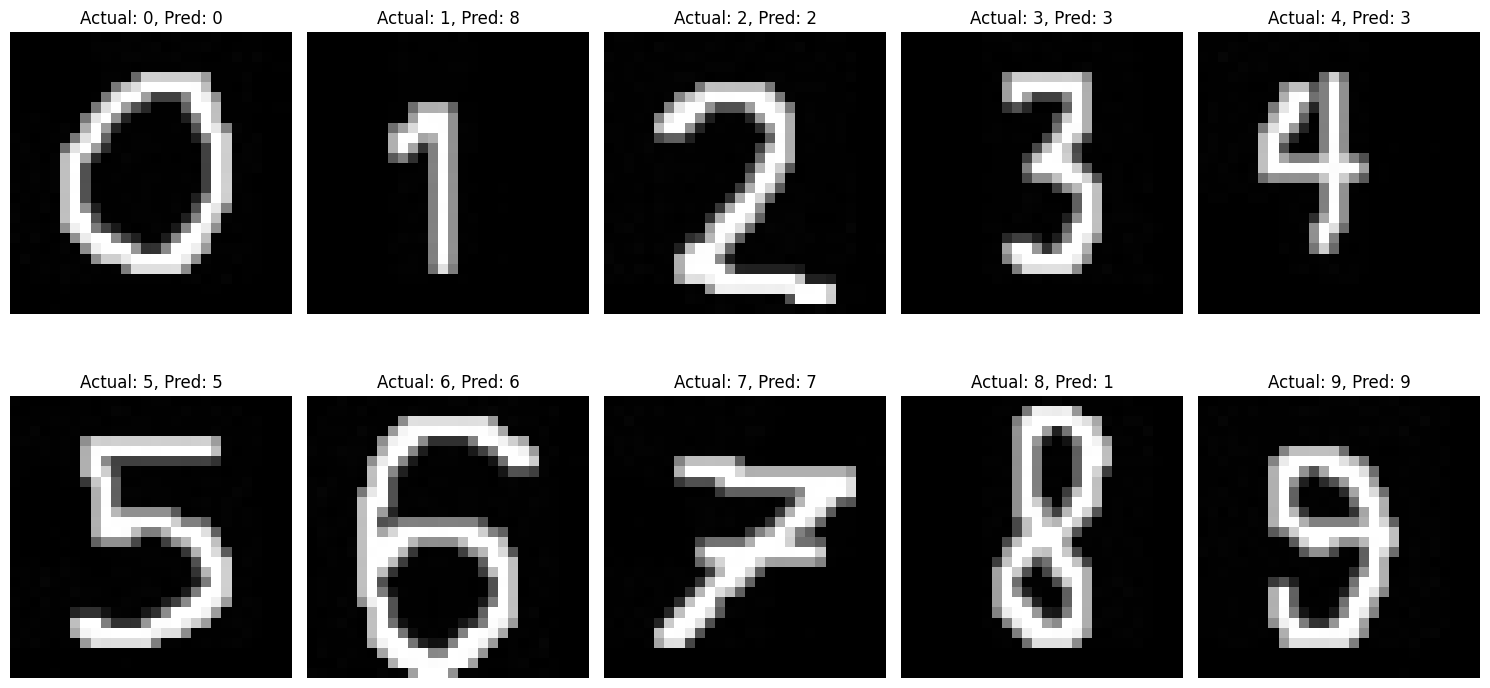

In [42]:
predictions = []
actual_labels = []

plt.figure(figsize=(15, 8))
for i in range(10):
    image_path = f'/content/images/{i}.jpg'

    img = cv2.imread(image_path)

    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    scaled_img = gray_img / 255.0

    #Mnist to dataset białych cyfr na czarnym tle
    scaled_img = 1.0 - scaled_img

    #Dostosowanie do modelu
    input_image = scaled_img.reshape(1, 28, 28, 1)

    prediction = model.predict(input_image)
    predicted_label = np.argmax(prediction)

    predictions.append(predicted_label)
    actual_labels.append(i)


    plt.subplot(2, 5, i + 1)
    plt.imshow(scaled_img.squeeze(), cmap='gray')
    plt.title(f'Actual: {i}, Pred: {predicted_label}')
    plt.axis('off')

plt.tight_layout()
plt.show()


Model uzyskał 70% accuracy.